In [ ]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical tests
from scipy import stats
import statsmodels.api as sm

# Machine learning (optional for feature engineering)
from sklearn.preprocessing import StandardScaler, LabelEncoder


In [ ]:
# Load dataset
df = pd.read_csv("7_real_estate_prices.csv")

# Quick look
df.head()
print(df.columns)   
df.shape
df.info()
df.describe()


Index(['property_id', 'listing_date', 'property_type', 'city',
       'neighborhood_tier', 'zipcode_crime_rate', 'school_rating',
       'distance_to_downtown_miles', 'walk_score', 'bedrooms', 'bathrooms',
       'square_feet', 'lot_size_sqft', 'stories', 'garage_spaces',
       'year_built', 'house_age', 'has_basement', 'has_pool',
       'overall_condition', 'kitchen_quality', 'hvac_condition',
       'roof_condition', 'renovation_year', 'years_since_renovation',
       'days_on_market', 'listing_season', 'market_trend', 'interest_rate',
       'has_fireplace', 'has_patio_deck', 'has_security_system', 'hoa_fees',
       'sale_price', 'high_value_property'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   property_id                 15000 non-null  object 
 1   listing_date             

,zipcode_crime_rate,school_rating,distance_to_downtown_miles,walk_score,bedrooms,bathrooms,square_feet,lot_size_sqft,stories,garage_spaces,year_built,house_age,renovation_year,years_since_renovation,days_on_market,interest_rate,hoa_fees,sale_price
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14250.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,6495.000000,15000.000000,15000.000000,15000.000000,14250.000000,1.500000e+04
mean,2.924115,6.993933,8.067307,54.130133,3.367600,2.393467,2145.772982,7930.426933,1.748400,1.601267,1982.066400,41.933600,2011.538106,28.633667,29.671667,6.503533,87.895368,7.827253e+05
std,2.922573,1.499838,7.818909,19.631552,1.116969,0.772889,532.833151,7697.859543,0.620583,0.911665,24.337798,24.337798,6.953233,23.718430,29.775319,0.804532,133.036807,1.622376e+05
min,0.000000,2.000000,0.500000,10.000000,1.000000,1.000000,248.000000,1000.000000,1.000000,0.000000,1940.000000,1.000000,2000.000000,1.000000,1.000000,3.050000,-109.000000,1.449700e+05
25%,0.870000,6.000000,2.300000,41.000000,3.000000,2.000000,1790.250000,2275.750000,1.000000,1.000000,1961.000000,20.000000,2006.000000,10.000000,8.000000,5.950000,0.000000,6.715468e+05
50%,2.030000,7.000000,5.600000,54.000000,3.000000,2.500000,2145.000000,5527.000000,2.000000,2.000000,1983.000000,41.000000,2012.000000,20.000000,21.000000,6.510000,0.000000,7.799125e+05
75%,4.032500,8.000000,11.100000,68.000000,4.000000,3.000000,2502.000000,10823.250000,2.000000,2.000000,2004.000000,63.000000,2018.000000,45.000000,42.000000,7.040000,196.000000,8.913538e+05
max,31.190000,10.000000,40.000000,100.000000,6.000000,4.000000,4154.000000,50000.000000,3.000000,3.000000,2023.000000,84.000000,2023.000000,84.000000,301.000000,9.740000,673.000000,1.372699e+06


In [ ]:
# Drop duplicates
df = df.drop_duplicates()

# Convert listing_date to datetime (day-first format)
df['listing_date'] = pd.to_datetime(df['listing_date'], errors='coerce', dayfirst=True)

# Handle missing values
df['square_feet'] = df['square_feet'].fillna(df['square_feet'].median())
df['hoa_fees'] = df['hoa_fees'].fillna(0)   # assume missing = no HOA fees
df['renovation_year'] = df['renovation_year'].fillna(0)  # 0 = never renovated

# Standardize categorical yes/no columns safely
binary_cols = [
    'has_basement','has_pool','has_fireplace',
    'has_patio_deck','has_security_system','high_value_property'
]

for col in binary_cols:
    df[col] = (
        df[col].astype(str)                # ensure string
              .str.strip().str.lower()     # clean whitespace/case
              .map({'yes':1,'no':0})       # map yes/no to 1/0
    )
    df[col] = df[col].fillna(0).astype(int)  # handle unexpected values

# Confirm cleaning
print(df[binary_cols].head())
print(df[binary_cols].dtypes)


   has_basement  has_pool  has_fireplace  has_patio_deck  has_security_system  \
0             0         0              0               0                    0   
1             0         0              0               0                    0   
2             0         0              0               0                    0   
3             0         0              0               0                    0   
4             0         0              0               0                    0   

   high_value_property  
0                    0  
1                    0  
2                    0  
3                    0  
4                    0  
has_basement           int32
has_pool               int32
has_fireplace          int32
has_patio_deck         int32
has_security_system    int32
high_value_property    int32
dtype: object


In [ ]:
#Feature Engineering
# Price per square foot
df['price_per_sqft'] = df['sale_price'] / df['square_feet']

# Property age (you already have house_age, but recompute for consistency)
df['property_age'] = 2026 - df['year_built']

# Renovated flag
df['is_renovated'] = df['renovation_year'].apply(lambda x: 1 if x > 0 else 0)

# Total rooms
df['total_rooms'] = df['bedrooms'] + df['bathrooms']

# Encode listing season
season_map = {'Spring':1, 'Summer':2, 'Fall':3, 'Winter':4}
df['listing_season_encoded'] = df['listing_season'].map(season_map)

# Encode categorical quality features
quality_cols = ['overall_condition','kitchen_quality','hvac_condition','roof_condition','market_trend']
for col in quality_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()
    df[col] = df[col].map({
        'poor':1, 'fair':2, 'average':3, 'good':4, 'excellent':5,
        'declining':1, 'stable':2, 'growing':3
    }).fillna(0).astype(int)


In [ ]:
#Hypotheses & Statistical Validation
from scipy import stats
import statsmodels.api as sm

# H1: Correlation
corr, pval = stats.pearsonr(df['square_feet'], df['sale_price'])
print("Correlation:", corr, "p-value:", pval)

# H2: T-test for renovation
renovated = df[df['is_renovated']==1]['sale_price']
not_renovated = df[df['is_renovated']==0]['sale_price']
t_stat, p_val = stats.ttest_ind(renovated, not_renovated)
print("T-test:", t_stat, "p-value:", p_val)

# H3: ANOVA for neighborhood tier
anova = stats.f_oneway(*[df[df['neighborhood_tier']==tier]['sale_price'] for tier in df['neighborhood_tier'].unique()])
print("ANOVA F-stat:", anova.statistic, "p-value:", anova.pvalue)

# H4: Regression (school_rating vs sale_price)
X = sm.add_constant(df['school_rating'])
model = sm.OLS(df['sale_price'], X).fit()
print(model.summary())


Correlation: 0.6150009379111867 p-value: nan
T-test: -0.8792155455653475 p-value: 0.3792985031851731
ANOVA F-stat: 435.7101174031593 p-value: 1.9866766752708903e-271
                            OLS Regression Results                            
Dep. Variable:             sale_price   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     230.1
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           1.38e-51
Time:                        11:35:03   Log-Likelihood:            -2.0112e+05
No. Observations:               15000   AIC:                         4.022e+05
Df Residuals:                   14998   BIC:                         4.023e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err         

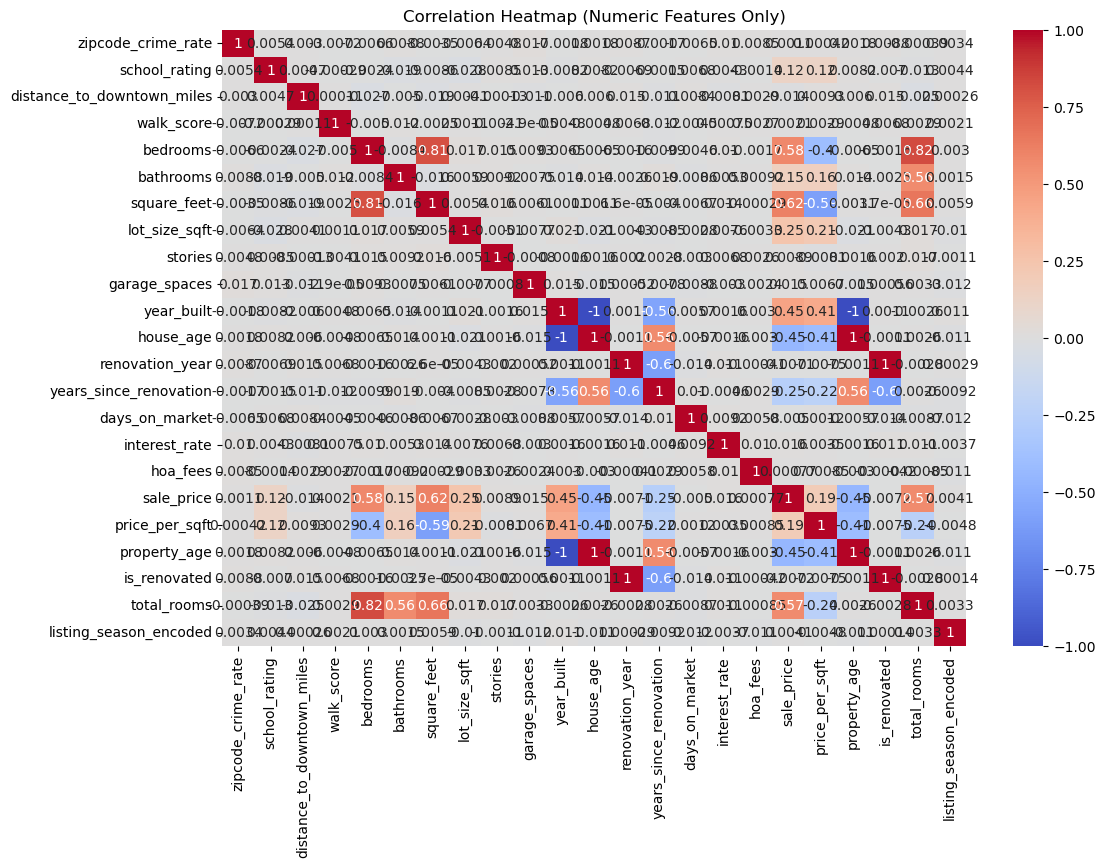

Top correlations with Sale Price:
 sale_price        1.000000
square_feet       0.615001
bedrooms          0.583443
total_rooms       0.569111
year_built        0.450907
lot_size_sqft     0.249739
price_per_sqft    0.194244
bathrooms         0.153058
school_rating     0.122919
interest_rate     0.015596
Name: sale_price, dtype: float64


In [ ]:
#EDA
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns (int and float types)
numeric_df = df.select_dtypes(include=['int64','float64'])

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()

# Optional: Top correlations with sale_price
corr_matrix = numeric_df.corr()
sale_price_corr = corr_matrix['sale_price'].sort_values(ascending=False)
print("Top correlations with Sale Price:\n", sale_price_corr.head(10))


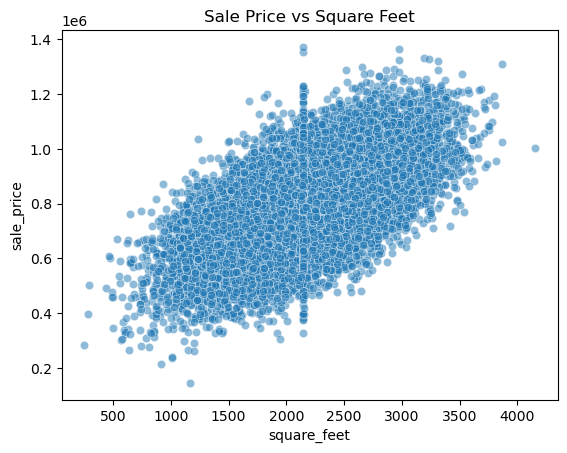

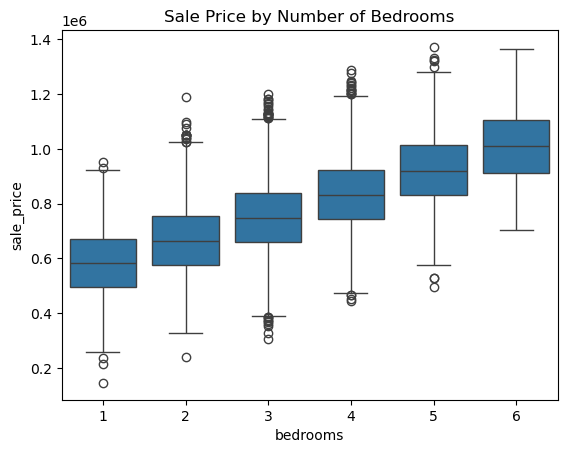

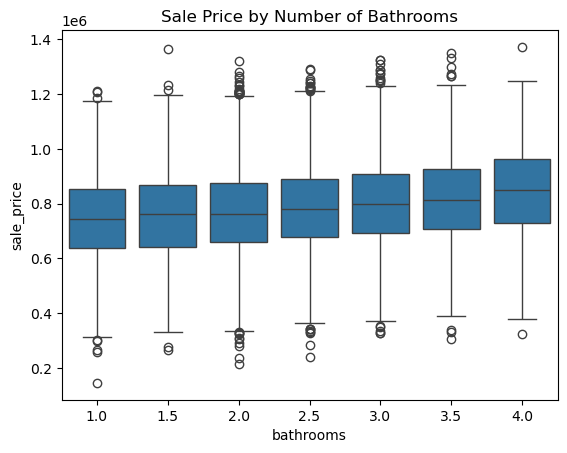

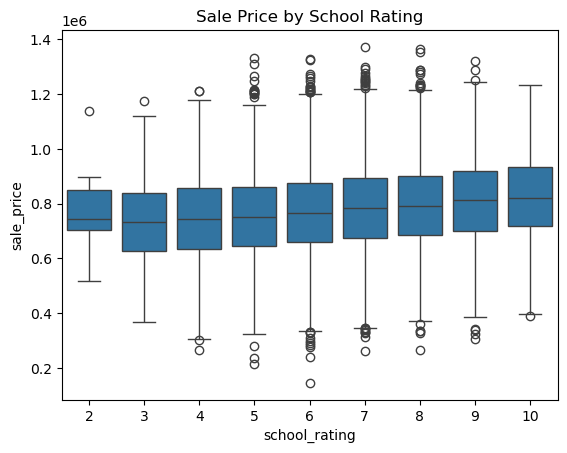

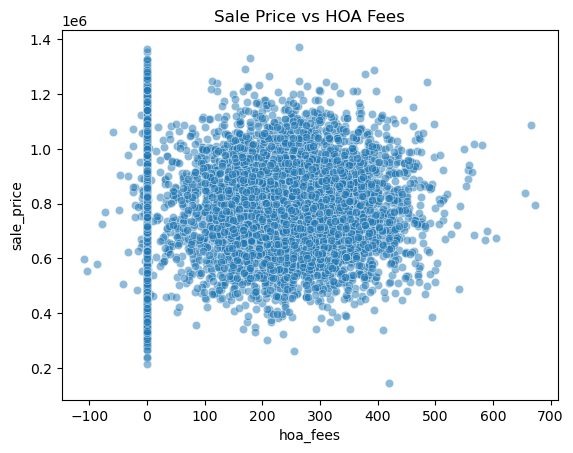

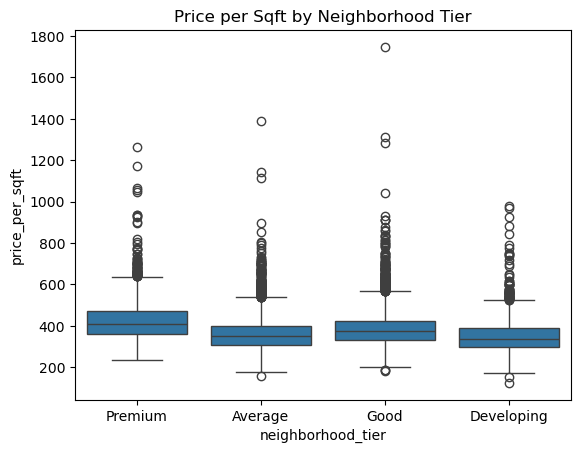

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Sale Price vs Square Feet
sns.scatterplot(x='square_feet', y='sale_price', data=df, alpha=0.5)
plt.title("Sale Price vs Square Feet")
plt.show()

# Sale Price vs Bedrooms
sns.boxplot(x='bedrooms', y='sale_price', data=df)
plt.title("Sale Price by Number of Bedrooms")
plt.show()

# Sale Price vs Bathrooms
sns.boxplot(x='bathrooms', y='sale_price', data=df)
plt.title("Sale Price by Number of Bathrooms")
plt.show()

# Sale Price vs School Rating
sns.boxplot(x='school_rating', y='sale_price', data=df)
plt.title("Sale Price by School Rating")
plt.show()

# Sale Price vs HOA Fees
sns.scatterplot(x='hoa_fees', y='sale_price', data=df, alpha=0.5)
plt.title("Sale Price vs HOA Fees")
plt.show()

# Price per sqft distribution by Neighborhood Tier
sns.boxplot(x='neighborhood_tier', y='price_per_sqft', data=df)
plt.title("Price per Sqft by Neighborhood Tier")
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Choose features (you can expand this list)
features = [
    'square_feet','bedrooms','bathrooms','school_rating',
    'hoa_fees','property_age','is_renovated','price_per_sqft',
    'listing_season_encoded','overall_condition','kitchen_quality',
    'hvac_condition','roof_condition'
]

X = df[features]
y = df['sale_price']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
